# Suspension Displacement Prediction — GRU RNN

Trains a GRU-based RNN to predict **body and tyre displacement** simultaneously from
ISO 8608 road profile inputs (Classes A–E).

### Dataset structure
- Road inputs `hxA–E` (unsuppressed) and `hsA–E` (suppressed): 100,000 samples each at Ts = 0.001 s
- Body/tyre outputs: 400,000 samples (4 concatenated periods); period 1 discarded as transient
- 5 classes × 3 usable periods = **15 signal pairs**

### Output constraint
The model output is passed through a **scaled tanh** activation: `tanh(x) * MAX_TRAVEL`.
This bounds predictions to the physically reachable displacement range derived from the data.

### Current configuration
`N_SAMPLES = 10_000` limits each signal pair to 10,000 samples for fast iteration on CPU.
Set `N_SAMPLES = None` to use the full 100,000 samples when running on GPU.

## 1. Imports & Device Setup

In [75]:
import time
import numpy as np
import scipy.io as sio
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from sklearn import preprocessing
import joblib

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce GTX 1660 Ti


In [76]:
import os
os.chdir(r'C:\Users\chees\OneDrive\Documents\PythonProjects\machineLearning\suspensionNN')

## 2. Configuration

All key hyperparameters in one place. Change `N_SAMPLES` to `None` for the full dataset on GPU.

In [77]:
# ── Data ─────────────────────────────────────────────────────────────────────
DATA_PATH = 'suspension_dataset.mat'   # update path if needed
N_SAMPLES = None   # samples per signal pair; set None for full 100k (GPU recommended)
SEQ_LEN   = 1000       # road history window [samples] = 500 ms at 1 kHz
STRIDE    = 5        # step between windows (reduces dataset size)

# ── Model ────────────────────────────────────────────────────────────────────
HIDDEN_DIM  = 128      # GRU hidden state size
FC_WIDTH    = 200     # width of each fully-connected layer in the MLP decoder
# MAX_BODY_TRAVEL and MAX_TYRE_TRAVEL are computed from the data after loading
MAX_BODY_TRAVEL = None
MAX_TYRE_TRAVEL = None

# ── Training ─────────────────────────────────────────────────────────────────
BATCH_SIZE   = 128
EPOCHS       = 300
LR_PATIENCE  = 10     # epochs before ReduceLROnPlateau reduces LR
LR_FACTOR    = 0.9
LR_MIN       = 1e-16
MAX_PATIENCE = 50     # early stopping patience
LOG_EVERY    = 5      # print batch progress every N batches

Ts = 0.001            # sampling interval [s]
N  = 100_000          # full period length in the .mat file

print('Configuration set.')
print(f'  N_SAMPLES = {N_SAMPLES}  (None = full 100k)')
print(f'  SEQ_LEN   = {SEQ_LEN} samples ({SEQ_LEN * Ts * 1000:.0f} ms of road history)')

Configuration set.
  N_SAMPLES = None  (None = full 100k)
  SEQ_LEN   = 1000 samples (1000 ms of road history)


## 3. Load Dataset

Classes loaded: 5 (A, B, C, D, E)
Samples per class: 100,000


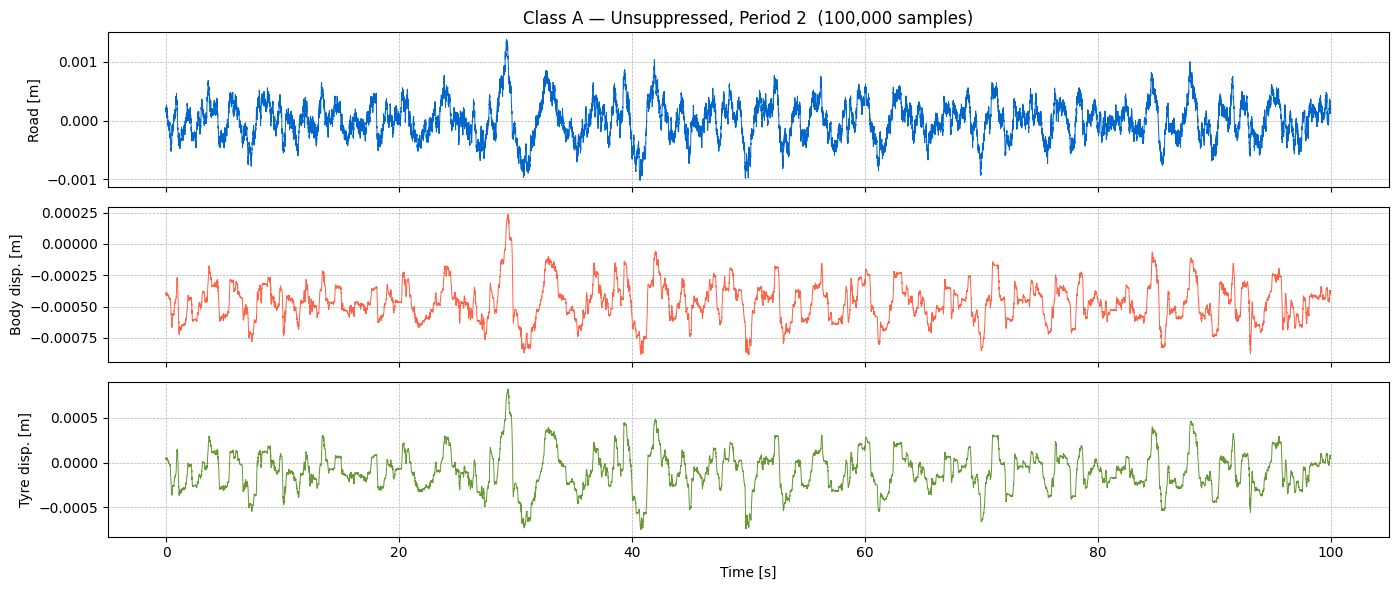

In [78]:
raw     = sio.loadmat(DATA_PATH)
CLASSES = ['A', 'B', 'C', 'D', 'E']
cap     = N_SAMPLES if N_SAMPLES is not None else N

road_signals, body_signals, tyre_signals = [], [], []

for cls in CLASSES:
    road_signals.append(raw[f'hx{cls}'].flatten()[:cap])
    body_signals.append(raw[f'bodyxsuppressed{cls}'].flatten()[N : N + cap])
    tyre_signals.append(raw[f'tirexsuppressed{cls}'].flatten()[N : N + cap])

print(f'Classes loaded: {len(road_signals)} ({", ".join(CLASSES)})')
print(f'Samples per class: {road_signals[0].shape[0]:,}')

# ── Sanity plot ───────────────────────────────────────────────────────────────
t_ax = np.arange(cap) * Ts
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
for ax, sig, lbl, col in zip(
    axes,
    [road_signals[0], body_signals[0], tyre_signals[0]],
    ['Road [m]', 'Body disp. [m]', 'Tyre disp. [m]'],
    ['#0066cc', 'tomato', '#669933']
):
    ax.plot(t_ax, sig, lw=0.7, color=col)
    ax.set_ylabel(lbl)
    ax.grid(True, linestyle='--', linewidth=0.5)
axes[0].set_title(f'Class A — Unsuppressed, Period 2  ({cap:,} samples)')
axes[2].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()

## 4. Normalisation (MinMax Scaling)

MinMaxScaler scales all signals to [0, 1]. Scalers are saved with `joblib` so they can be
reloaded at inference time to inverse-transform predictions back to metres.

In [79]:
# ── Compute global z-score statistics ─────────────────────────────────────────
all_road = np.concatenate(road_signals)
all_body = np.concatenate(body_signals)
all_tyre = np.concatenate(tyre_signals)

road_mean, road_std = float(all_road.mean()), float(all_road.std())
body_mean, body_std = float(all_body.mean()), float(all_body.std())
tyre_mean, tyre_std = float(all_tyre.mean()), float(all_tyre.std())

# Save for inference
scaler_stats = {
    'road_mean': road_mean, 'road_std': road_std,
    'body_mean': body_mean, 'body_std': body_std,
    'tyre_mean': tyre_mean, 'tyre_std': tyre_std,
}
joblib.dump(scaler_stats, 'zscore_stats.pkl')
print('Z-score stats saved to zscore_stats.pkl')

print(f'Road  mean={road_mean:+.6f} m   std={road_std:.6f} m')
print(f'Body  mean={body_mean:+.6f} m   std={body_std:.6f} m')
print(f'Tyre  mean={tyre_mean:+.6f} m   std={tyre_std:.6f} m')

# ── Normalise ─────────────────────────────────────────────────────────────────
road_norm = [(s - road_mean) / road_std for s in road_signals]
body_norm = [(s - body_mean) / body_std for s in body_signals]
tyre_norm = [(s - tyre_mean) / tyre_std for s in tyre_signals]

print(f'\nRoad scaled range: [{np.concatenate(road_norm).min():.3f}, {np.concatenate(road_norm).max():.3f}]')
print(f'Body scaled range: [{np.concatenate(body_norm).min():.3f}, {np.concatenate(body_norm).max():.3f}]')
print(f'Tyre scaled range: [{np.concatenate(tyre_norm).min():.3f}, {np.concatenate(tyre_norm).max():.3f}]')

Z-score stats saved to zscore_stats.pkl
Road  mean=-0.000000 m   std=0.001813 m
Body  mean=-0.000436 m   std=0.001809 m
Tyre  mean=-0.000096 m   std=0.001744 m

Road scaled range: [-5.999, 8.161]
Body scaled range: [-8.663, 7.379]
Tyre scaled range: [-6.498, 8.163]


## 5. Build Sliding-Window Sequences

Uses `numpy.lib.stride_tricks.sliding_window_view` for fully vectorised window construction.
The dataset is then randomly permuted and converted to `TensorDataset`, matching the
lab9 pattern of shuffling before splitting.

In [80]:
Xs, ys = [], []

for road, body, tyre in zip(road_norm, body_norm, tyre_norm):
    windows = np.lib.stride_tricks.sliding_window_view(road, SEQ_LEN)  # (L-SEQ_LEN+1, SEQ_LEN)
    windows = windows[::STRIDE]
    targets = np.stack([
        body[SEQ_LEN - 1 :: STRIDE],
        tyre[SEQ_LEN - 1 :: STRIDE]
    ], axis=1)
    n = min(len(windows), len(targets))
    Xs.append(windows[:n])
    ys.append(targets[:n])

X_seq = np.concatenate(Xs, axis=0).astype(np.float32)   # (M, SEQ_LEN)
Y_seq = np.concatenate(ys, axis=0).astype(np.float32)   # (M, 2)

print(f'Total samples  : {X_seq.shape[0]:,}')
print(f'Input shape    : {X_seq.shape}  (N, SEQ_LEN)')
print(f'Output shape   : {Y_seq.shape}  (N, 2)')

# ── Randomly permute, convert to tensors, wrap in TensorDataset ──────────────
perm = np.random.permutation(X_seq.shape[0])
X_tensor = torch.tensor(X_seq[perm]).unsqueeze(-1)   # (M, SEQ_LEN, 1)
Y_tensor = torch.tensor(Y_seq[perm])                 # (M, 2)

# After building X_tensor and Y_tensor, move everything to GPU once
X_tensor = X_tensor.to(device)
Y_tensor = Y_tensor.to(device)

dataset    = TensorDataset(X_tensor, Y_tensor)

# ── Train / Val split  90 / 10 ────────────────────────────────────────────────
train_size = int(0.9 * len(dataset))
train_set, val_set = random_split(dataset, [train_size, len(dataset) - train_size])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE)

print(f'\nTrain size: {len(train_set):,}')
print(f'Validation size: {len(val_set):,}')

Total samples  : 99,005
Input shape    : (99005, 1000)  (N, SEQ_LEN)
Output shape   : (99005, 2)  (N, 2)

Train size: 89,104
Validation size: 9,901


## 6. GRU Model

Two stacked GRU layers with ReLU activations between them, followed by a 3-layer MLP decoder.
The final output is passed through a scaled tanh to enforce physical displacement limits.
Architecture matches the `GRUNet` pattern from lab9.

In [81]:
# -------------------------
# Define GRU-based Neural Network
# -------------------------
class SuspensionGRU(nn.Module):
    def __init__(self, input_size, output_size, hidden_size=32, fc_width=100):
        """
        A deep GRU model with two stacked GRU layers followed by three fully connected (dense) layers.
        Used to predict the current stress state given a time history of strain tensors.

        Parameters:
            input_size (int): Number of features in the input (e.g., 6 strain components).
            output_size (int): Number of outputs to predict (e.g., 6 stress components).
            hidden_size (int): Dimensionality of the hidden state in each GRU layer.
            fc_width (int): Number of units in each dense layer.
        """
        super().__init__()

        # First GRU layer
        self.gru1 = nn.GRU(input_size, hidden_size, batch_first=True)

        # Second GRU layer
        self.gru2 = nn.GRU(hidden_size, hidden_size, batch_first=True)

        # Fully connected layers
        self.fc1 = nn.Linear(hidden_size, fc_width)
        self.fc2 = nn.Linear(fc_width, fc_width)
        self.fc3 = nn.Linear(fc_width, fc_width)

        # Output layer
        self.fc4 = nn.Linear(fc_width, output_size)

        # Activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        """
        Forward pass through the network.

        Parameters:
            x (tensor): Input tensor of shape (batch_size, sequence_length, input_size)

        Returns:
            tensor: Predicted output of shape (batch_size, output_size)
        """
        # First GRU layer: processes the input sequence and returns outputs at all timesteps
        # We discard the second output (hidden state) because we manually extract the last timestep later
        x, _ = self.gru1(x)
        x = self.relu(x)  # Apply non-linearity after the first GRU

        # Second GRU layer: takes the sequence from the first GRU and further refines it
        x, _ = self.gru2(x)
        x = self.relu(x)  # Another ReLU activation for stability and expressiveness

        # Select the output from the final timestep only (many-to-one setup)
        # Shape changes from (batch_size, seq_len, hidden_size) → (batch_size, hidden_size)
        x = x[:, -1, :]

        # Fully connected layers (MLP): map the final GRU output to the stress prediction
        x = self.relu(self.fc1(x))  # First dense layer with ReLU
        x = self.relu(self.fc2(x))  # Second dense layer with ReLU (Residual connection)
        x = self.relu(self.fc3(x))  # Third dense layer with ReLU (Residual connection)

        # Final output layer (no activation): maps to 6 stress components
        return self.fc4(x)


model = SuspensionGRU(
    input_size  = 1,
    output_size = 2,
    hidden_size = HIDDEN_DIM,
    fc_width    = FC_WIDTH
).to(device)

## 7. Training

Uses **NAdam** optimizer, **ReduceLROnPlateau** scheduler (`factor=0.9`, `patience=10`,
`min_lr=1e-16`), and early stopping after 50 epochs without improvement — matching lab9.

In [82]:
criterion = nn.MSELoss()
optimizer = torch.optim.NAdam(model.parameters())
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = 'min',
    factor   = LR_FACTOR,
    patience = LR_PATIENCE,
    min_lr   = LR_MIN
)

best_val_loss     = float('inf')
early_stop_count  = 0
train_loss_history = []
val_loss_history   = []

print('Starting training...\n')
total_start = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for batch_idx, (xb, yb) in enumerate(train_loader, 1):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        if batch_idx % LOG_EVERY == 0 or batch_idx == len(train_loader):
            print(f'  Epoch {epoch:03d} | Batch {batch_idx:>4d}/{len(train_loader)}'
                  f' | Batch Loss: {loss.item():.3e}', end='\r')

    train_loss /= len(train_loader)

    # ── Validate ─────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_pred = model(xb)
            loss = criterion(val_pred, yb)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    scheduler.step(val_loss)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    epoch_time = time.time() - epoch_start
    print(f'\nEpoch {epoch:3d} | Train Loss: {train_loss:.3e} | Val Loss: {val_loss:.3e} | [{epoch_time:.1f}s]')

    # ── Checkpoint & early stopping ──────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        early_stop_count = 0
        torch.save(model.state_dict(), 'best_suspension_gru.pt')
    else:
        early_stop_count += 1
        if early_stop_count > MAX_PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

print(f'\nTraining complete in {(time.time()-total_start)/60:.1f} min')
print(f'Best validation MSE: {best_val_loss:.3e}')

Starting training...

  Epoch 001 | Batch  697/697 | Batch Loss: 2.303e-01
Epoch   1 | Train Loss: 2.349e-01 | Val Loss: 2.729e-01 | [44.4s]
  Epoch 002 | Batch  697/697 | Batch Loss: 1.621e-02
Epoch   2 | Train Loss: 1.261e-01 | Val Loss: 7.512e-02 | [41.8s]
  Epoch 003 | Batch  697/697 | Batch Loss: 3.488e-02
Epoch   3 | Train Loss: 6.130e-02 | Val Loss: 7.744e-02 | [42.5s]
  Epoch 004 | Batch  697/697 | Batch Loss: 3.875e-02
Epoch   4 | Train Loss: 4.477e-02 | Val Loss: 5.977e-02 | [42.3s]
  Epoch 005 | Batch  697/697 | Batch Loss: 1.992e-02
Epoch   5 | Train Loss: 3.389e-02 | Val Loss: 3.009e-02 | [41.4s]
  Epoch 006 | Batch  697/697 | Batch Loss: 8.897e-03
Epoch   6 | Train Loss: 2.858e-02 | Val Loss: 2.403e-02 | [41.3s]
  Epoch 007 | Batch  697/697 | Batch Loss: 5.978e-03
Epoch   7 | Train Loss: 2.455e-02 | Val Loss: 2.162e-02 | [45.7s]
  Epoch 008 | Batch  697/697 | Batch Loss: 6.411e-03
Epoch   8 | Train Loss: 2.025e-02 | Val Loss: 2.149e-02 | [44.5s]
  Epoch 009 | Batch  697/6

## 8. Training and Validation Loss

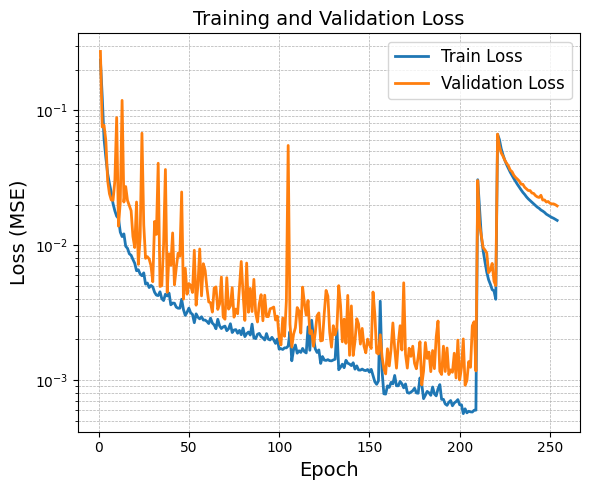

In [92]:
plt.figure(figsize=(6, 5))
plt.semilogy(range(1, len(train_loss_history) + 1), train_loss_history, label='Train Loss', linewidth=2)
plt.semilogy(range(1, len(val_loss_history)   + 1), val_loss_history,   label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss (MSE)', fontsize=14)
plt.title('Training and Validation Loss', fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 9. Evaluation on Validation Set

## 10. Prediction vs Ground Truth

In [132]:
# ═══════════════════════════════════════════════════════════════════════════════
# Evaluate on a single road class (continuous, unshuffled, unsuppressed only)
# ═══════════════════════════════════════════════════════════════════════════════

# ── Choose signal ─────────────────────────────────────────────────────────────
ROAD_CLASS = 'C'      # 'A', 'B', 'C', 'D', 'E'

# ── Load raw signal pair (unsuppressed, period 2 only) ────────────────────────
road_raw = raw[f'hx{ROAD_CLASS}'].flatten()[:cap]
body_raw = raw[f'bodyxsuppressed{ROAD_CLASS}'].flatten()[N : N + cap]
tyre_raw = raw[f'tirexsuppressed{ROAD_CLASS}'].flatten()[N : N + cap]

# ── Scale ─────────────────────────────────────────────────────────────────────
road_sc = (road_raw - road_mean) / road_std

# ── Build continuous windows (stride=1, no shuffle) ───────────────────────────
windows = np.lib.stride_tricks.sliding_window_view(road_sc, SEQ_LEN)
n = min(len(windows), len(body_raw) - SEQ_LEN + 1)

X_inf = torch.tensor(windows[:n], dtype=torch.float32).unsqueeze(-1).to(device)

# ── Inference in batches ──────────────────────────────────────────────────────
model.load_state_dict(torch.load('best_suspension_gru.pt', map_location=device))
model.eval()

preds_list = []
with torch.no_grad():
    for i in range(0, n, BATCH_SIZE):
        preds_list.append(model(X_inf[i:i+BATCH_SIZE]).cpu().numpy())

preds_sc = np.concatenate(preds_list, axis=0)

# ── Inverse-transform to metres ──────────────────────────────────────────────
preds_body = preds_sc[:, 0] * body_std + body_mean
preds_tyre = preds_sc[:, 1] * tyre_std + tyre_mean
targets_body = body_raw[SEQ_LEN - 1 : SEQ_LEN - 1 + n]
targets_tyre = tyre_raw[SEQ_LEN - 1 : SEQ_LEN - 1 + n]

# ── Metrics ───────────────────────────────────────────────────────────────────
title = f'Class {ROAD_CLASS} — Unsuppressed — Period 2'

def report(pred, true, label):
    rmse = np.sqrt(np.mean((pred - true) ** 2))
    mae  = np.mean(np.abs(pred - true))
    print(f'  {label:6s}  RMSE: {rmse*1000:.4f} mm   MAE: {mae*1000:.4f} mm')

print(f'{title}')
print(f'Samples: {n:,}\n')
report(preds_body, targets_body, 'Body')
report(preds_tyre, targets_tyre, 'Tyre')

Class C — Unsuppressed — Period 2
Samples: 99,001

  Body    RMSE: 0.0268 mm   MAE: 0.0211 mm
  Tyre    RMSE: 0.0284 mm   MAE: 0.0223 mm


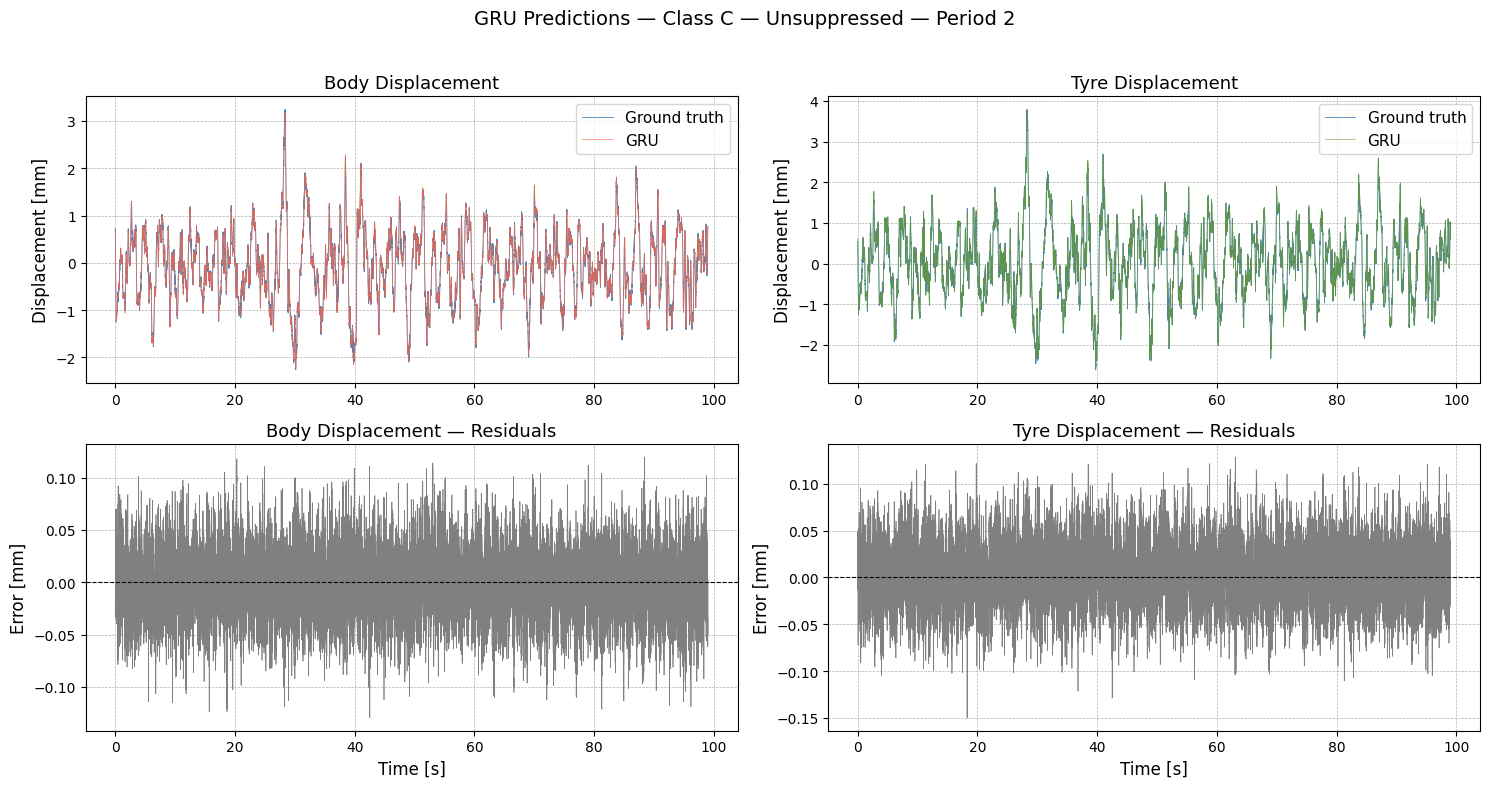

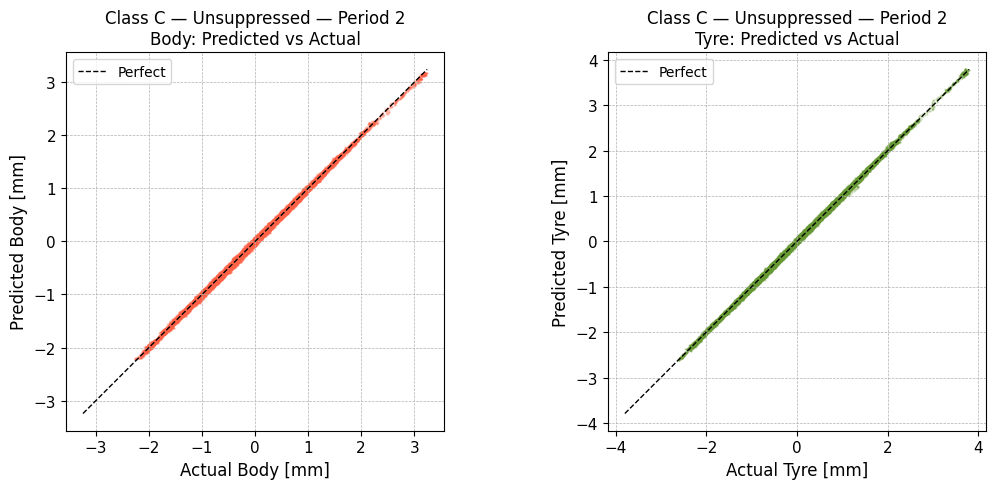

In [123]:
# ═══════════════════════════════════════════════════════════════════════════════
# Plot continuous predictions for the selected road class
# ═══════════════════════════════════════════════════════════════════════════════

t_plot = np.arange(n) * Ts   # true 1 kHz time axis (stride=1)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

plot_cfg = [
    (axes[0, 0], axes[1, 0], targets_body, preds_body, 'Body Displacement', 'tomato'),
    (axes[0, 1], axes[1, 1], targets_tyre, preds_tyre, 'Tyre Displacement', '#669933'),
]
for ax_top, ax_bot, truth, pred, label, col in plot_cfg:
    ax_top.plot(t_plot, truth*1000, lw=0.6, color='steelblue', label='Ground truth')
    ax_top.plot(t_plot, pred*1000,  lw=0.5, color=col, alpha=0.8, label='GRU')
    ax_top.set_title(label, fontsize=13)
    ax_top.set_ylabel('Displacement [mm]', fontsize=12)
    ax_top.legend(fontsize=11)
    ax_top.grid(True, linestyle='--', linewidth=0.5)

    residual = (pred - truth) * 1000
    ax_bot.plot(t_plot, residual, lw=0.5, color='grey')
    ax_bot.axhline(0, color='k', lw=0.8, ls='--')
    ax_bot.set_title(f'{label} — Residuals', fontsize=13)
    ax_bot.set_ylabel('Error [mm]', fontsize=12)
    ax_bot.set_xlabel('Time [s]', fontsize=12)
    ax_bot.grid(True, linestyle='--', linewidth=0.5)

plt.suptitle(f'GRU Predictions — {title}', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ── Scatter ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
for ax, pred, truth, label, col in [
    (ax1, preds_body, targets_body, 'Body', 'tomato'),
    (ax2, preds_tyre, targets_tyre, 'Tyre', '#669933')
]:
    ax.scatter(truth*1000, pred*1000, s=0.3, alpha=0.3, color=col)
    lim = max(np.abs(truth).max(), np.abs(pred).max()) * 1000
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1, label='Perfect')
    ax.set_xlabel(f'Actual {label} [mm]', fontsize=12)
    ax.set_ylabel(f'Predicted {label} [mm]', fontsize=12)
    ax.set_title(f'{title}\n{label}: Predicted vs Actual', fontsize=12)
    ax.set_aspect('equal')
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

Class C — Unsuppressed
Samples: 99,001

  Body    RMSE: 0.1384 mm   MAE: 0.0862 mm
  Tyre    RMSE: 0.0752 mm   MAE: 0.0549 mm


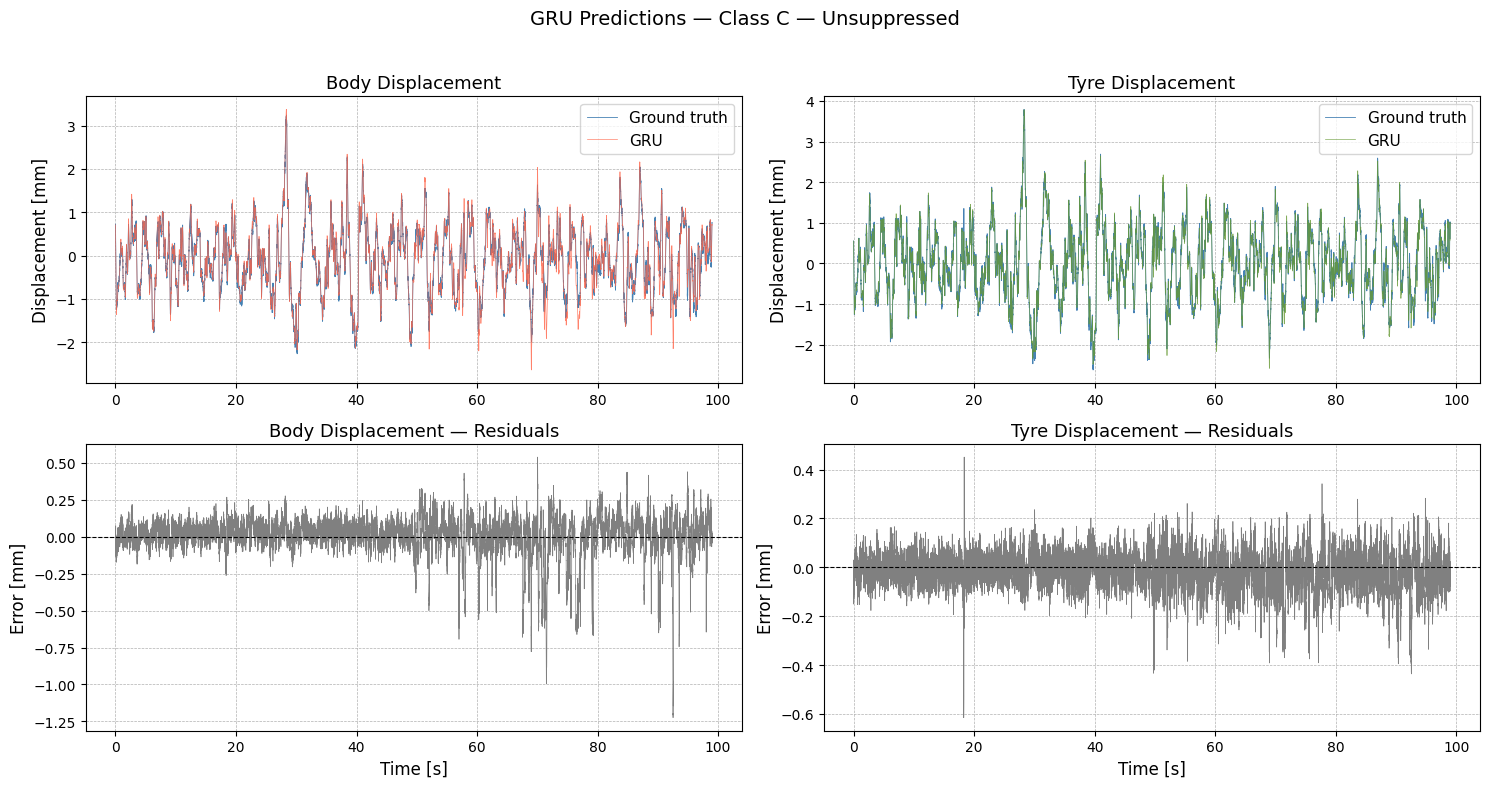

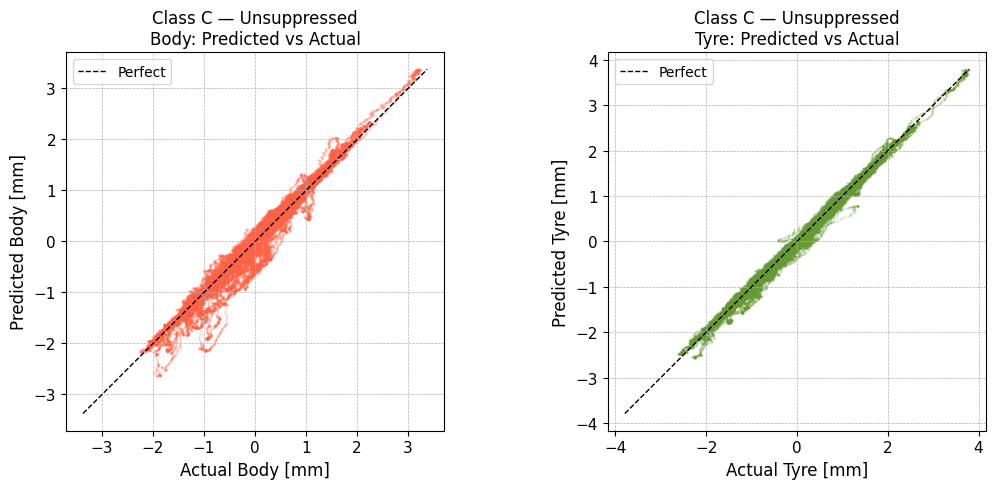

In [124]:
# ── Compare against best model ────────────────────────────────────────────────
model.load_state_dict(torch.load('gru_zscore_h128_fc200_seq1000_s5_50k.pt', map_location=device))
model.eval()

preds_list = []
with torch.no_grad():
    for i in range(0, n, BATCH_SIZE):
        preds_list.append(model(X_inf[i:i+BATCH_SIZE]).cpu().numpy())

preds_sc = np.concatenate(preds_list, axis=0)

preds_body = preds_sc[:, 0] * body_std + body_mean
preds_tyre = preds_sc[:, 1] * tyre_std + tyre_mean
targets_body = body_raw[SEQ_LEN - 1 : SEQ_LEN - 1 + n]
targets_tyre = tyre_raw[SEQ_LEN - 1 : SEQ_LEN - 1 + n]

# ── Metrics ───────────────────────────────────────────────────────────────────
title = f'Class {ROAD_CLASS} — Unsuppressed'

def report(pred, true, label):
    rmse = np.sqrt(np.mean((pred - true) ** 2))
    mae  = np.mean(np.abs(pred - true))
    print(f'  {label:6s}  RMSE: {rmse*1000:.4f} mm   MAE: {mae*1000:.4f} mm')

print(f'{title}')
print(f'Samples: {n:,}\n')
report(preds_body, targets_body, 'Body')
report(preds_tyre, targets_tyre, 'Tyre')

# ── Time-domain + residuals ───────────────────────────────────────────────────
t_plot = np.arange(n) * Ts

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

plot_cfg = [
    (axes[0, 0], axes[1, 0], targets_body, preds_body, 'Body Displacement', 'tomato'),
    (axes[0, 1], axes[1, 1], targets_tyre, preds_tyre, 'Tyre Displacement', '#669933'),
]
for ax_top, ax_bot, truth, pred, label, col in plot_cfg:
    ax_top.plot(t_plot, truth*1000, lw=0.6, color='steelblue', label='Ground truth')
    ax_top.plot(t_plot, pred*1000,  lw=0.5, color=col, alpha=0.8, label='GRU')
    ax_top.set_title(label, fontsize=13)
    ax_top.set_ylabel('Displacement [mm]', fontsize=12)
    ax_top.legend(fontsize=11)
    ax_top.grid(True, linestyle='--', linewidth=0.5)

    residual = (pred - truth) * 1000
    ax_bot.plot(t_plot, residual, lw=0.5, color='grey')
    ax_bot.axhline(0, color='k', lw=0.8, ls='--')
    ax_bot.set_title(f'{label} — Residuals', fontsize=13)
    ax_bot.set_ylabel('Error [mm]', fontsize=12)
    ax_bot.set_xlabel('Time [s]', fontsize=12)
    ax_bot.grid(True, linestyle='--', linewidth=0.5)

plt.suptitle(f'GRU Predictions — {title}', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ── Scatter ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
for ax, pred, truth, label, col in [
    (ax1, preds_body, targets_body, 'Body', 'tomato'),
    (ax2, preds_tyre, targets_tyre, 'Tyre', '#669933')
]:
    ax.scatter(truth*1000, pred*1000, s=0.3, alpha=0.3, color=col)
    lim = max(np.abs(truth).max(), np.abs(pred).max()) * 1000
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1, label='Perfect')
    ax.set_xlabel(f'Actual {label} [mm]', fontsize=12)
    ax.set_ylabel(f'Predicted {label} [mm]', fontsize=12)
    ax.set_title(f'{title}\n{label}: Predicted vs Actual', fontsize=12)
    ax.set_aspect('equal')
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

In [133]:
def metrics(pred, true, name):
    rmse = np.sqrt(np.mean((pred - true)**2))
    mae = np.mean(np.abs(pred - true))
    nrmse_range = rmse / (true.max() - true.min())
    nrmse_std = rmse / np.std(true)
    corr = np.corrcoef(pred, true)[0, 1]

    print(f"{name}")
    print(f"RMSE: {rmse*1000:.4f} mm")
    print(f"MAE:  {mae*1000:.4f} mm")
    print(f"NRMSE / range: {nrmse_range*100:.2f}%")
    print(f"NRMSE / std:   {nrmse_std*100:.2f}%")
    print(f"Correlation:   {corr:.4f}")

metrics(preds_body, targets_body, "Body")
metrics(preds_tyre, targets_tyre, "Tyre")

Body
RMSE: 0.0268 mm
MAE:  0.0211 mm
NRMSE / range: 0.49%
NRMSE / std:   3.58%
Correlation:   0.9994
Tyre
RMSE: 0.0284 mm
MAE:  0.0223 mm
NRMSE / range: 0.44%
NRMSE / std:   3.28%
Correlation:   0.9995


In [126]:
def speed_bump(t, start, width, height):
    road = np.zeros_like(t)

    ramp = width * 0.25
    flat = width * 0.5

    t1 = start
    t2 = t1 + ramp
    t3 = t2 + flat
    t4 = t3 + ramp

    # ramp up
    mask = (t >= t1) & (t < t2)
    tau = (t[mask] - t1) / ramp
    road[mask] = height * tau

    # flat top
    mask = (t >= t2) & (t < t3)
    road[mask] = height

    # ramp down
    mask = (t >= t3) & (t < t4)
    tau = (t[mask] - t3) / ramp
    road[mask] = height * (1 - tau)

    return road

t = np.linspace(0, 10, 10000)  # 10 seconds at 1 kHz
road_bump = speed_bump(t, start=4.5, width=1.0, height=0.003)  # 3mm

freq = 2.0  # Hz — near body natural frequency
road_bump = 0.006 * np.sin(2 * np.pi * freq * t) 

print(len(road_bump))
print(len(t))

10000
10000


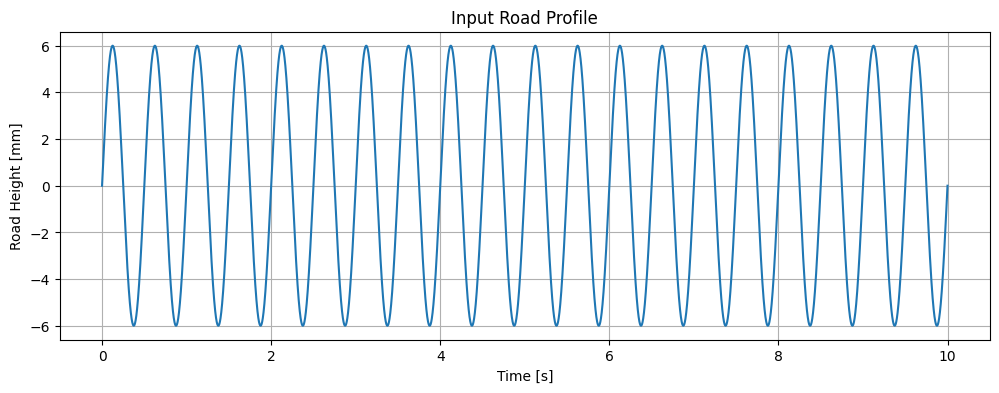

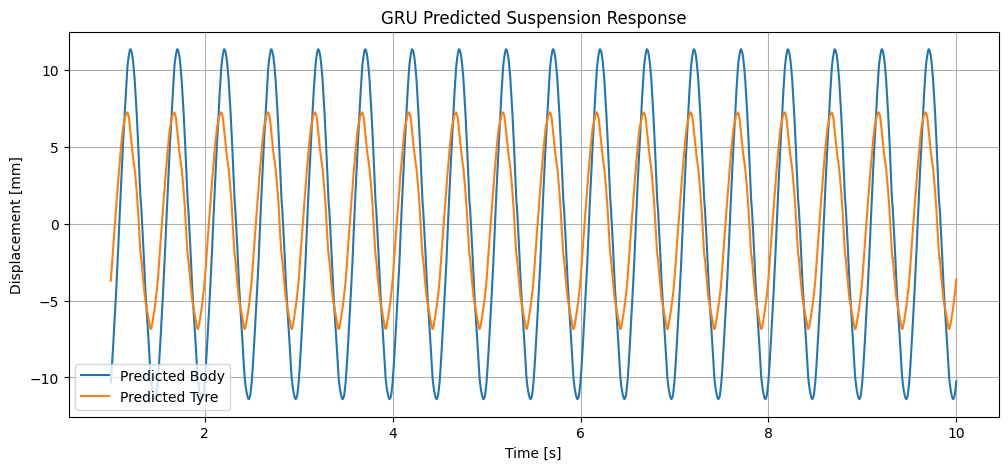

In [127]:
# ── Scale ─────────────────────────────────────────────────────────────────────
road_sc = (road_bump - road_mean) / road_std

# ── Build continuous windows (stride=1, no shuffle) ───────────────────────────
windows = np.lib.stride_tricks.sliding_window_view(road_sc, SEQ_LEN)
n = min(len(windows), len(body_raw) - SEQ_LEN + 1)

X_inf = torch.tensor(windows[:n], dtype=torch.float32).unsqueeze(-1).to(device)
n = X_inf.shape[0]

# ------------------------------------------------------------
# 4. Load model and predict
# ------------------------------------------------------------

model.load_state_dict(torch.load(
    'best_suspension_gru.pt',
    map_location=device
))

model.eval()

preds_list = []

with torch.no_grad():
    for i in range(0, n, BATCH_SIZE):
        batch = X_inf[i:i + BATCH_SIZE]
        preds_list.append(model(batch).cpu().numpy())

preds_sc = np.concatenate(preds_list, axis=0)


# ------------------------------------------------------------
# 5. Convert predictions back to metres
# ------------------------------------------------------------

preds_body = preds_sc[:, 0] * body_std + body_mean
preds_tyre = preds_sc[:, 1] * tyre_std + tyre_mean

t_pred = t[SEQ_LEN - 1:]


# ------------------------------------------------------------
# 6. Plot road input and predicted response
# ------------------------------------------------------------

plt.figure(figsize=(12, 4))
plt.plot(t, road_bump * 1000)
plt.xlabel("Time [s]")
plt.ylabel("Road Height [mm]")
plt.title("Input Road Profile")
plt.grid(True)
plt.show()


plt.figure(figsize=(12, 5))
plt.plot(t_pred, preds_body * 1000, label="Predicted Body")
plt.plot(t_pred, preds_tyre * 1000, label="Predicted Tyre")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [mm]")
plt.title("GRU Predicted Suspension Response")
plt.legend()
plt.grid(True)
plt.show()

Quarter-Car Parameters:
  Sprung mass (body):    Ms  = 2.45 kg
  Unsprung mass (tyre):  Mus = 0.85 kg
  Suspension spring:     Ks  = 900.0 N/m
  Tyre spring:           Kus = 2500.0 N/m
  Suspension damper:     Bs  = 7.5 Ns/m
  Tyre damper:           Bus = 5.0 Ns/m

  Body natural freq:     3.05 Hz
  Tyre natural freq:     8.63 Hz

Quarter-car simulation complete.
  Body peak:  21.06 mm
  Tyre peak:  10.47 mm
  GRU body peak:  11.42 mm
  GRU tyre peak:  7.25 mm


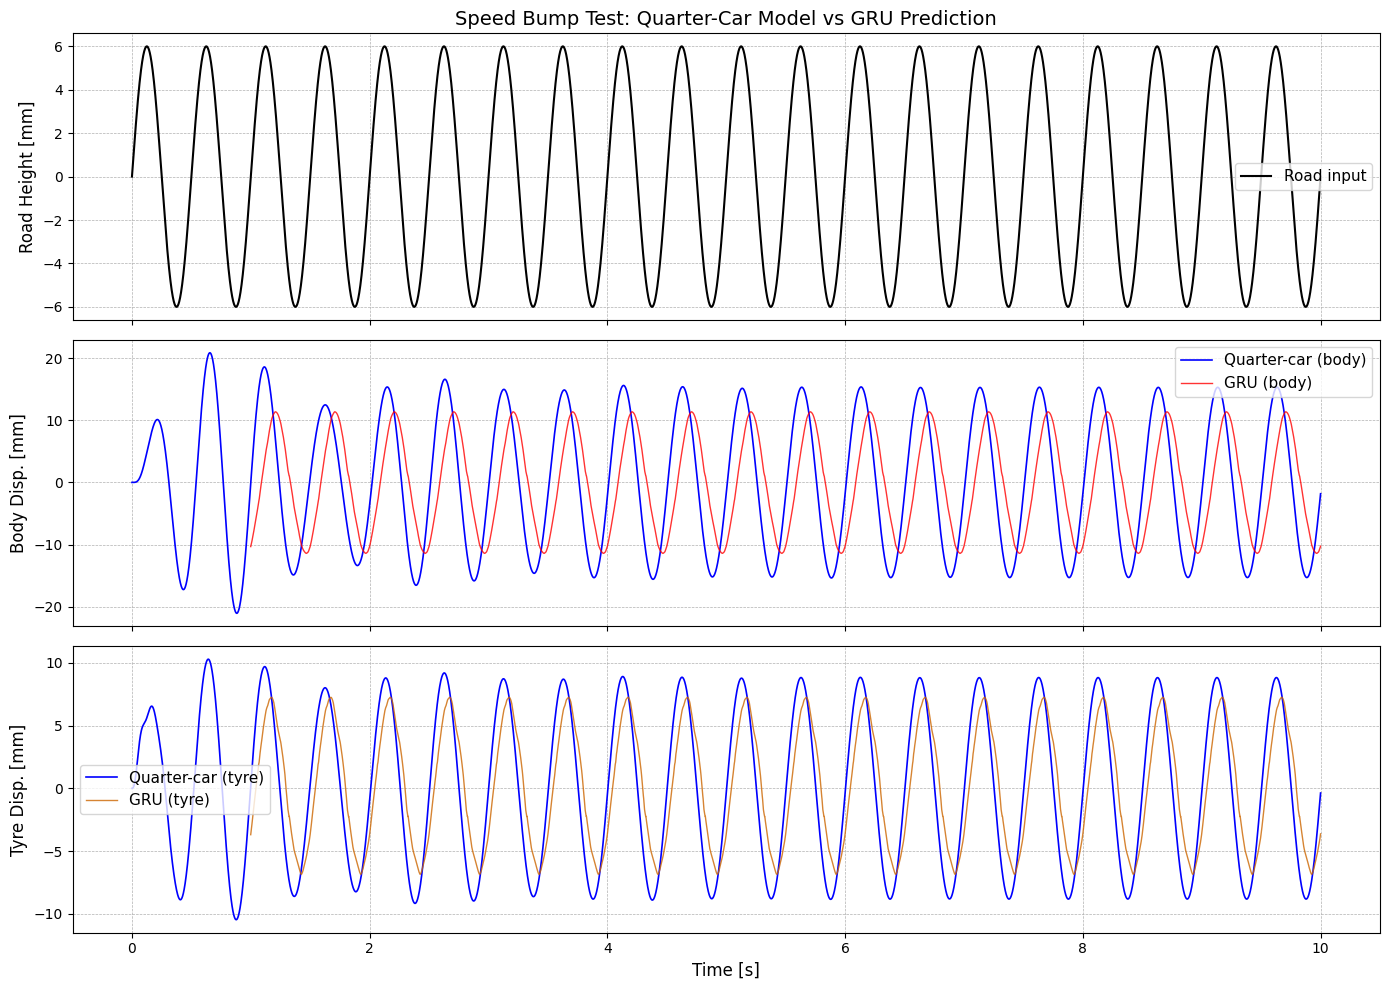

In [128]:
# ═══════════════════════════════════════════════════════════════════════════════
# Quarter-Car Model Simulation vs GRU Prediction
# ═══════════════════════════════════════════════════════════════════════════════
from scipy.integrate import solve_ivp

# ── Quanser Active Suspension bench parameters (typical published values) ─────
# These are bench-scale values, NOT full vehicle — the Quanser rig uses plates
# on linear bearings, not a real car chassis.
# Source: Quanser courseware and papers using this rig.
# If you have the exact values from your lab's Quanser manual, replace these.

Ms  = 2.45     # sprung mass (body plate) [kg]
Mus = 0.85     # unsprung mass (tyre plate) [kg]
Ks  = 900.0    # suspension spring stiffness [N/m]
Kus = 2500.0   # tyre spring stiffness [N/m]
Bs  = 7.5      # suspension damping coefficient [Ns/m]
Bus = 5.0      # tyre damping coefficient [Ns/m]

print(f'Quarter-Car Parameters:')
print(f'  Sprung mass (body):    Ms  = {Ms} kg')
print(f'  Unsprung mass (tyre):  Mus = {Mus} kg')
print(f'  Suspension spring:     Ks  = {Ks} N/m')
print(f'  Tyre spring:           Kus = {Kus} N/m')
print(f'  Suspension damper:     Bs  = {Bs} Ns/m')
print(f'  Tyre damper:           Bus = {Bus} Ns/m')

# Natural frequencies
wn_body = np.sqrt(Ks / Ms) / (2 * np.pi)
wn_tyre = np.sqrt(Kus / Mus) / (2 * np.pi)
print(f'\n  Body natural freq:     {wn_body:.2f} Hz')
print(f'  Tyre natural freq:     {wn_tyre:.2f} Hz')


# ── Quarter-car state-space model ─────────────────────────────────────────────
# State vector: [x_s, dx_s, x_us, dx_us]
# x_s  = body displacement
# x_us = tyre (unsprung mass) displacement
# r    = road profile input

def quarter_car_odes(t_val, state, t_road, road_profile):
    x_s, dx_s, x_us, dx_us = state

    # Interpolate road input at current time
    r = np.interp(t_val, t_road, road_profile)

    # Equations of motion:
    # Ms * ddx_s   = -Ks*(x_s - x_us) - Bs*(dx_s - dx_us)
    # Mus * ddx_us = Ks*(x_s - x_us) + Bs*(dx_s - dx_us) - Kus*(x_us - r) - Bus*(dx_us - dr)
    # We approximate dr ≈ 0 for simplicity (or compute finite diff)

    # Road velocity (finite difference approximation)
    dt_road = t_road[1] - t_road[0]
    idx = int(t_val / dt_road)
    idx = min(idx, len(road_profile) - 2)
    dr = (road_profile[idx + 1] - road_profile[idx]) / dt_road

    ddx_s  = (-Ks * (x_s - x_us) - Bs * (dx_s - dx_us)) / Ms
    ddx_us = (Ks * (x_s - x_us) + Bs * (dx_s - dx_us)
              - Kus * (x_us - r) - Bus * (dx_us - dr)) / Mus

    return [dx_s, ddx_s, dx_us, ddx_us]


# ── Generate the same speed bump ──────────────────────────────────────────────
t_sim = np.linspace(0, 10, 10000)  # 10 seconds at 1 kHz
# ── Solve the ODE ─────────────────────────────────────────────────────────────
sol = solve_ivp(
    quarter_car_odes,
    t_span=(t_sim[0], t_sim[-1]),
    y0=[0, 0, 0, 0],             # starts at rest
    t_eval=t_sim,
    args=(t_sim, road_bump),
    method='RK45',
    max_step=0.001                # match 1 kHz sampling
)

qc_body = sol.y[0]    # body displacement [m]
qc_tyre = sol.y[2]    # tyre displacement [m]

print(f'\nQuarter-car simulation complete.')
print(f'  Body peak:  {np.max(np.abs(qc_body))*1000:.2f} mm')
print(f'  Tyre peak:  {np.max(np.abs(qc_tyre))*1000:.2f} mm')
print(f'  GRU body peak:  {np.max(np.abs(preds_body))*1000:.2f} mm')
print(f'  GRU tyre peak:  {np.max(np.abs(preds_tyre))*1000:.2f} mm')


# ── Plot: Quarter-car vs GRU ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Road input
axes[0].plot(t_sim, road_bump * 1000, 'k', lw=1.5, label='Road input')
axes[0].set_ylabel('Road Height [mm]', fontsize=12)
axes[0].set_title('Speed Bump Test: Quarter-Car Model vs GRU Prediction', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', linewidth=0.5)

# Body displacement
axes[1].plot(t_sim, qc_body * 1000, 'b', lw=1.2, label='Quarter-car (body)')
axes[1].plot(t_pred, preds_body * 1000, 'r', lw=1.0, alpha=0.8, label='GRU (body)')
axes[1].set_ylabel('Body Disp. [mm]', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', linewidth=0.5)

# Tyre displacement
axes[2].plot(t_sim, qc_tyre * 1000, 'b', lw=1.2, label='Quarter-car (tyre)')
axes[2].plot(t_pred, preds_tyre * 1000, '#cc6600', lw=1.0, alpha=0.8, label='GRU (tyre)')
axes[2].set_ylabel('Tyre Disp. [mm]', fontsize=12)
axes[2].set_xlabel('Time [s]', fontsize=12)
axes[2].legend(fontsize=11)
axes[2].grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

Optimised parameters:
  Ks  = 591.9 N/m
  Kus = 1002.4 N/m
  Bs  = 28.6 Ns/m
  Bus = 79.0 Ns/m


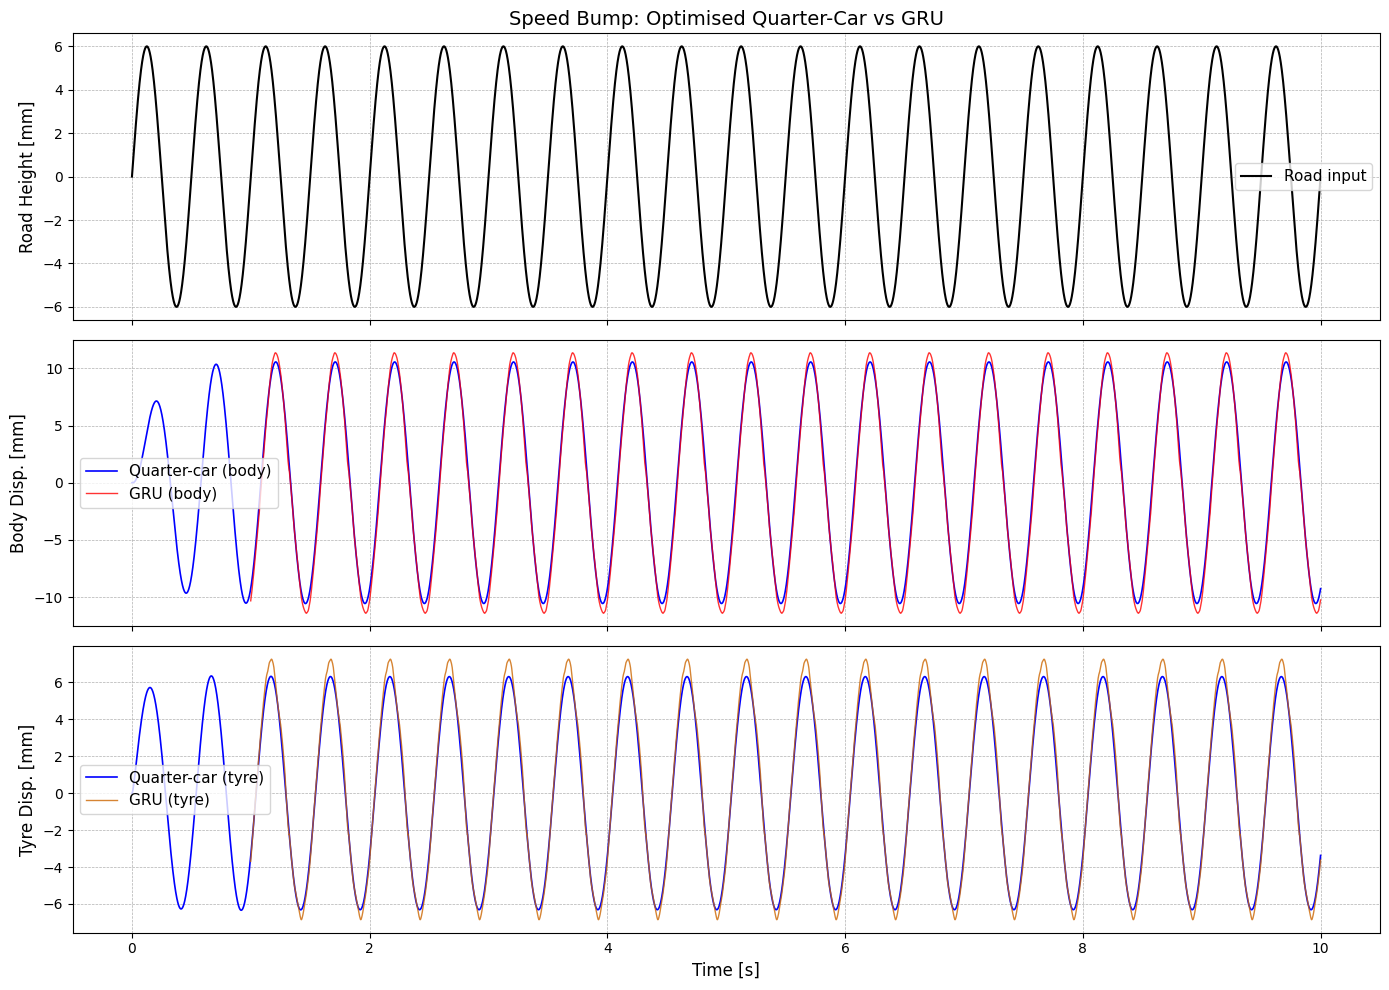

In [129]:
from scipy.signal import lsim, StateSpace

def cost(params):
    Ks, Kus, Bs, Bus = params
    if any(p <= 0 for p in params):
        return 1e10
    try:
        # State: [x_s, dx_s, x_us, dx_us]
        # Inputs: [road_displacement, road_velocity]
        A = [[0, 1, 0, 0],
             [-Ks/Ms, -Bs/Ms, Ks/Ms, Bs/Ms],
             [0, 0, 0, 1],
             [Ks/Mus, Bs/Mus, -(Ks+Kus)/Mus, -(Bs+Bus)/Mus]]
        B = [[0, 0],
             [0, 0],
             [0, 0],
             [Kus/Mus, Bus/Mus]]     # both road disp and road vel affect tyre
        C = [[1, 0, 0, 0],
             [0, 0, 1, 0]]
        D = [[0, 0],
             [0, 0]]

        sys = StateSpace(A, B, C, D)

        # Compute road velocity via finite differences
        road_vel = np.gradient(road_bump, t_sim[1] - t_sim[0])
        U = np.column_stack([road_bump, road_vel])   # (N, 2) input

        _, y, _ = lsim(sys, U=U, T=t_sim)

        gru_body_interp = np.interp(t_sim, t_pred, preds_body)
        gru_tyre_interp = np.interp(t_sim, t_pred, preds_tyre)

        err = (np.mean((y[:, 0] - gru_body_interp)**2)
             + np.mean((y[:, 1] - gru_tyre_interp)**2))
        return err
    except:
        return 1e10

x0 = [900, 5000, 30, 15]
result = minimize(cost, x0, method='Nelder-Mead',
                  options={'maxiter': 500})

Ks_opt, Kus_opt, Bs_opt, Bus_opt = result.x
print(f'Optimised parameters:')
print(f'  Ks  = {Ks_opt:.1f} N/m')
print(f'  Kus = {Kus_opt:.1f} N/m')
print(f'  Bs  = {Bs_opt:.1f} Ns/m')
print(f'  Bus = {Bus_opt:.1f} Ns/m')

A = [[0, 1, 0, 0],
     [-Ks_opt/Ms, -Bs_opt/Ms, Ks_opt/Ms, Bs_opt/Ms],
     [0, 0, 0, 1],
     [Ks_opt/Mus, Bs_opt/Mus, -(Ks_opt+Kus_opt)/Mus, -(Bs_opt+Bus_opt)/Mus]]
B = [[0, 0], [0, 0], [0, 0], [Kus_opt/Mus, Bus_opt/Mus]]
C = [[1, 0, 0, 0], [0, 0, 1, 0]]
D = [[0, 0], [0, 0]]

sys_opt = StateSpace(A, B, C, D)
road_vel = np.gradient(road_bump, t_sim[1] - t_sim[0])
U = np.column_stack([road_bump, road_vel])
_, y_opt, _ = lsim(sys_opt, U=U, T=t_sim)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(t_sim, road_bump * 1000, 'k', lw=1.5, label='Road input')
axes[0].set_ylabel('Road Height [mm]', fontsize=12)
axes[0].set_title('Speed Bump: Optimised Quarter-Car vs GRU', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', linewidth=0.5)

axes[1].plot(t_sim, y_opt[:, 0] * 1000, 'b', lw=1.2, label='Quarter-car (body)')
axes[1].plot(t_pred, preds_body * 1000, 'r', lw=1.0, alpha=0.8, label='GRU (body)')
axes[1].set_ylabel('Body Disp. [mm]', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', linewidth=0.5)

axes[2].plot(t_sim, y_opt[:, 1] * 1000, 'b', lw=1.2, label='Quarter-car (tyre)')
axes[2].plot(t_pred, preds_tyre * 1000, '#cc6600', lw=1.0, alpha=0.8, label='GRU (tyre)')
axes[2].set_ylabel('Tyre Disp. [mm]', fontsize=12)
axes[2].set_xlabel('Time [s]', fontsize=12)
axes[2].legend(fontsize=11)
axes[2].grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [130]:
# ═══════════════════════════════════════════════════════════════════════════════
# Generate independent ISO 8608 road profiles and validate GRU vs quarter-car
# ═══════════════════════════════════════════════════════════════════════════════
from scipy.signal import lsim, StateSpace

def generate_iso8608_profile(class_level, n_samples, Ts, seed=None):
    if seed is not None:
        np.random.seed(seed)
    
    # Target RMS amplitudes matched to actual training data [metres]
    target_rms = {'A': 0.0003, 'B': 0.0008, 'C': 0.002, 'D': 0.005, 'E': 0.012}
    
    # Generate white noise and filter to get 1/f^2 spectral shape (ISO 8608)
    N = n_samples
    fs = 1.0 / Ts
    
    white = np.random.randn(N)
    freqs = np.fft.rfftfreq(N, d=Ts)
    freqs[0] = 1.0  # avoid division by zero
    
    # 1/f^2 filter (waviness w=2 means PSD falls as f^-2)
    filt = 1.0 / freqs
    spectrum = np.fft.rfft(white) * filt
    road = np.fft.irfft(spectrum, n=N)
    
    # Remove DC offset and scale to target RMS
    road = road - np.mean(road)
    road = road * (target_rms[class_level] / np.std(road))
    
    return road


# ── Generate fresh profiles for each class ────────────────────────────────────
# These are completely independent from the training data — different random seeds
test_profiles = {}
for cls in ['A', 'B', 'C', 'D', 'E']:
    test_profiles[cls] = generate_iso8608_profile(cls, 10000, Ts, seed=hash(cls) % 2**32)

# ── Quarter-car simulation function ───────────────────────────────────────────
def simulate_quarter_car(road, t, Ks, Kus, Bs, Bus, Ms, Mus):
    A = [[0, 1, 0, 0],
         [-Ks/Ms, -Bs/Ms, Ks/Ms, Bs/Ms],
         [0, 0, 0, 1],
         [Ks/Mus, Bs/Mus, -(Ks+Kus)/Mus, -(Bs+Bus)/Mus]]
    B = [[0, 0], [0, 0], [0, 0], [Kus/Mus, Bus/Mus]]
    C = [[1, 0, 0, 0], [0, 0, 1, 0]]
    D = [[0, 0], [0, 0]]
    
    sys = StateSpace(A, B, C, D)
    road_vel = np.gradient(road, Ts)
    U = np.column_stack([road, road_vel])
    _, y, _ = lsim(sys, U=U, T=t)
    return y[:, 0], y[:, 1]  # body, tyre


# ── Run GRU and quarter-car on each generated profile ─────────────────────────
model.eval()

print(f'{"Class":<8} {"GRU Body pk":<14} {"QC Body pk":<14} {"GRU Tyre pk":<14} {"QC Tyre pk":<14}')
print('-' * 64)

for cls in ['A', 'B', 'C', 'D', 'E']:
    road = test_profiles[cls]
    t_test = np.arange(len(road)) * Ts
    
    # ── GRU prediction ────────────────────────────────────────────────────────
    road_sc = (road - road_mean) / road_std
    windows = np.lib.stride_tricks.sliding_window_view(road_sc, SEQ_LEN)
    n = len(windows)
    X_inf = torch.tensor(windows[:n], dtype=torch.float32).unsqueeze(-1).to(device)
    
    preds_list = []
    with torch.no_grad():
        for i in range(0, n, BATCH_SIZE):
            preds_list.append(model(X_inf[i:i+BATCH_SIZE]).cpu().numpy())
    preds_sc = np.concatenate(preds_list, axis=0)
    gru_body = preds_sc[:, 0] * body_std + body_mean
    gru_tyre = preds_sc[:, 1] * tyre_std + tyre_mean
    
    # ── Quarter-car simulation ────────────────────────────────────────────────
    qc_body, qc_tyre = simulate_quarter_car(
        road, t_test, Ks_opt, Kus_opt, Bs_opt, Bus_opt, Ms, Mus
    )
    # Trim quarter-car to match GRU length
    qc_body = qc_body[SEQ_LEN-1 : SEQ_LEN-1+n]
    qc_tyre = qc_tyre[SEQ_LEN-1 : SEQ_LEN-1+n]
    
    print(f'{cls:<8} {np.max(np.abs(gru_body))*1000:>10.2f} mm  '
          f'{np.max(np.abs(qc_body))*1000:>10.2f} mm  '
          f'{np.max(np.abs(gru_tyre))*1000:>10.2f} mm  '
          f'{np.max(np.abs(qc_tyre))*1000:>10.2f} mm')


Class    GRU Body pk    QC Body pk     GRU Tyre pk    QC Tyre pk    
----------------------------------------------------------------
A              0.74 mm        0.79 mm        0.48 mm        0.76 mm
B              1.65 mm        2.15 mm        1.64 mm        1.99 mm
C              5.51 mm        5.99 mm        5.34 mm        5.60 mm
D             11.49 mm       10.88 mm       10.40 mm       11.31 mm
E             16.78 mm       36.19 mm       16.58 mm       32.04 mm


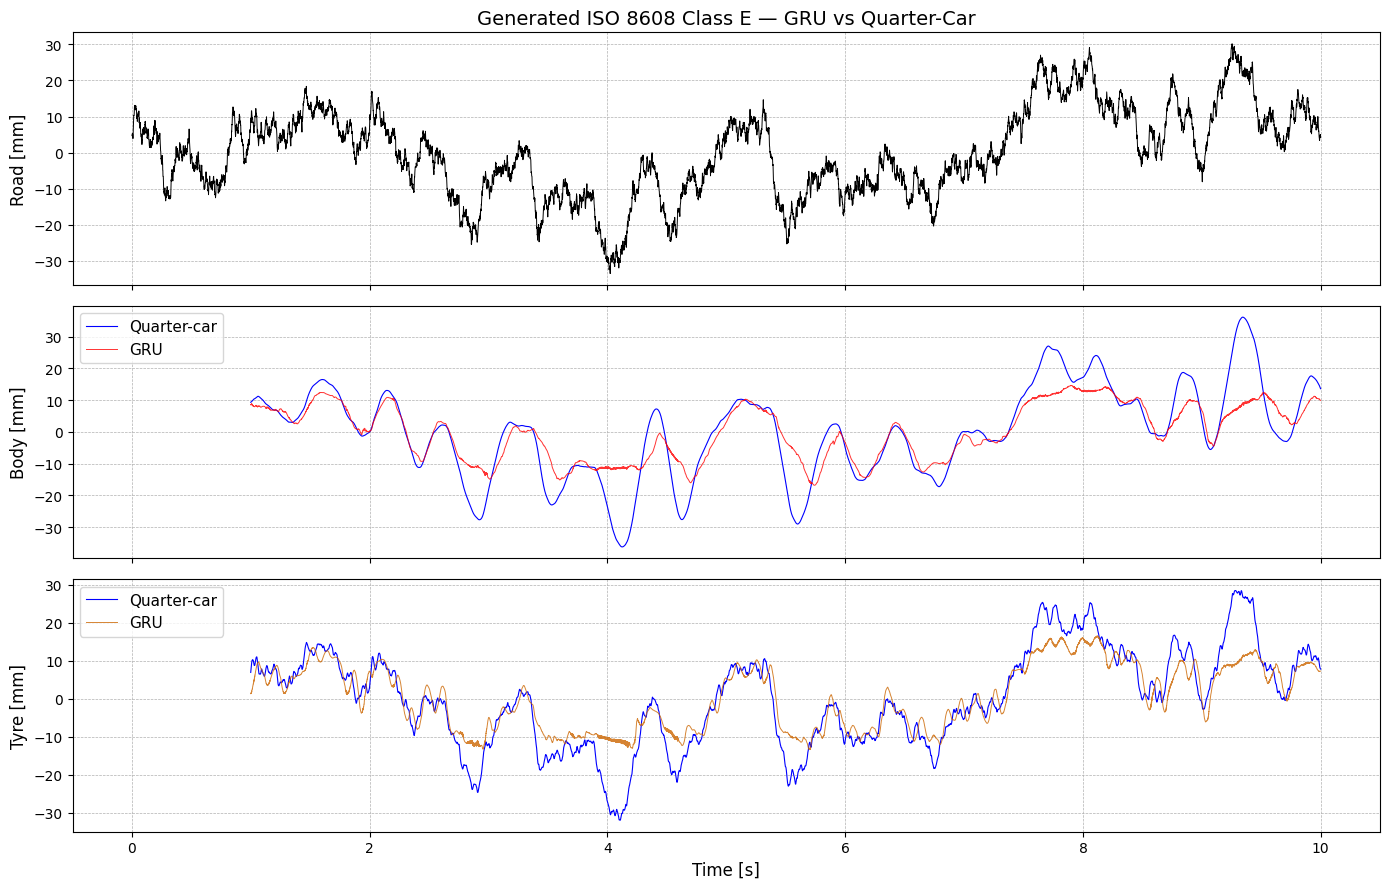

In [131]:

# ── Detailed plot for one class ───────────────────────────────────────────────
PLOT_CLASS = 'E'
road = test_profiles[PLOT_CLASS]
t_test = np.arange(len(road)) * Ts

road_sc = (road - road_mean) / road_std
windows = np.lib.stride_tricks.sliding_window_view(road_sc, SEQ_LEN)
n = len(windows)
X_inf = torch.tensor(windows[:n], dtype=torch.float32).unsqueeze(-1).to(device)

preds_list = []
with torch.no_grad():
    for i in range(0, n, BATCH_SIZE):
        preds_list.append(model(X_inf[i:i+BATCH_SIZE]).cpu().numpy())
preds_sc = np.concatenate(preds_list, axis=0)
gru_body = preds_sc[:, 0] * body_std + body_mean
gru_tyre = preds_sc[:, 1] * tyre_std + tyre_mean

qc_body, qc_tyre = simulate_quarter_car(
    road, t_test, Ks_opt, Kus_opt, Bs_opt, Bus_opt, Ms, Mus
)
t_pred = t_test[SEQ_LEN-1 : SEQ_LEN-1+n]
qc_body = qc_body[SEQ_LEN-1 : SEQ_LEN-1+n]
qc_tyre = qc_tyre[SEQ_LEN-1 : SEQ_LEN-1+n]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(t_test, road * 1000, 'k', lw=0.7)
axes[0].set_ylabel('Road [mm]', fontsize=12)
axes[0].set_title(f'Generated ISO 8608 Class {PLOT_CLASS} — GRU vs Quarter-Car', fontsize=14)
axes[0].grid(True, linestyle='--', linewidth=0.5)

axes[1].plot(t_pred, qc_body * 1000, 'b', lw=0.8, label='Quarter-car')
axes[1].plot(t_pred, gru_body * 1000, 'r', lw=0.7, alpha=0.8, label='GRU')
axes[1].set_ylabel('Body [mm]', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', linewidth=0.5)

axes[2].plot(t_pred, qc_tyre * 1000, 'b', lw=0.8, label='Quarter-car')
axes[2].plot(t_pred, gru_tyre * 1000, '#cc6600', lw=0.7, alpha=0.8, label='GRU')
axes[2].set_ylabel('Tyre [mm]', fontsize=12)
axes[2].set_xlabel('Time [s]', fontsize=12)
axes[2].legend(fontsize=11)
axes[2].grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()